/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


Predicted Per Capita Income in 2020: 41288.69409441762


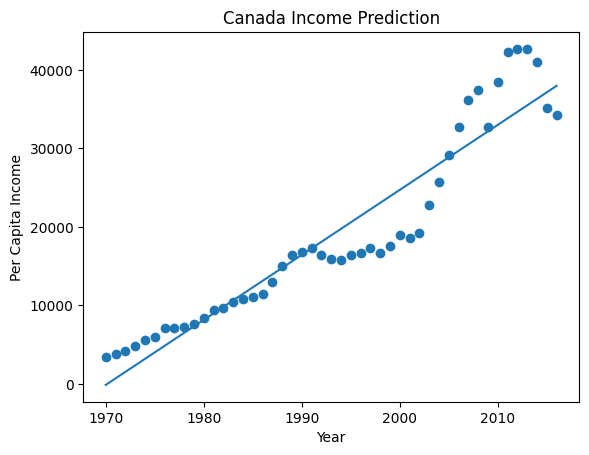

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('canada_per_capita_income.csv')

# Independent and dependent variables
X = df[['year']]
y = df['per capita income (US$)']

# Create model
model = LinearRegression()
model.fit(X, y)

# Predict income for 2020
income_2020 = model.predict([[2020]])
print("Predicted Per Capita Income in 2020:", income_2020[0])

# Plot
plt.scatter(X, y)
plt.plot(X, model.predict(X))
plt.xlabel("Year")
plt.ylabel("Per Capita Income")
plt.title("Canada Income Prediction")
plt.show()

In [20]:
import pandas as pd
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv('salary.csv')

# Handle missing values: Fill NaN in 'YearsExperience' with the median
df['YearsExperience'] = df['YearsExperience'].fillna(df['YearsExperience'].median())

X = df[['YearsExperience']]
y = df['Salary']

model = LinearRegression()
model.fit(X, y)

# Predict salary for 12 years experience
salary_12 = model.predict([[12]])
print("Predicted Salary for 12 years experience:", salary_12[0])

Predicted Salary for 12 years experience: 139574.04095965804


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [23]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import math

df = pd.read_csv('hiring.csv')

# Create a mapping dictionary for word representations of numbers
word_to_num = {
    'zero': 0, 'one': 1, 'two': 2, 'three': 3, 'four': 4,
    'five': 5, 'six': 6, 'seven': 7, 'eight': 8, 'nine': 9,
    'ten': 10, 'eleven': 11, 'twelve': 12
}

# Fill NaN values in 'experience' with the string 'zero' first
df['experience'] = df['experience'].fillna('zero')
# Apply the mapping to convert word-based numbers to integers
df['experience'] = df['experience'].apply(lambda x: word_to_num.get(x, x))
# Convert the column to numeric, coercing any remaining errors to NaN, then fill with 0 and convert to int
df['experience'] = pd.to_numeric(df['experience'], errors='coerce').fillna(0).astype(int)

# Fill missing test scores
median_test_score = math.floor(df['test_score(out of 10)'].median())
df['test_score(out of 10)'] = df['test_score(out of 10)'].fillna(median_test_score)

# Use correct column names for X and y
X = df[['experience','test_score(out of 10)','interview_score(out of 10)']]
y = df['salary($)']

model = LinearRegression()
model.fit(X, y)

# Predictions
# Ensure the input for prediction matches the order and expected features
pred1 = model.predict([[2,9,6]])
pred2 = model.predict([[12,10,10]])

print("Salary (2 yr, 9 test, 6 interview):", pred1[0])
print("Salary (12 yr, 10 test, 10 interview):", pred2[0])

Salary (2 yr, 9 test, 6 interview): 53205.96797671033
Salary (12 yr, 10 test, 10 interview): 92002.18340611353


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [22]:
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv('1000_Companies.csv')

# One hot encoding
df = pd.get_dummies(df, drop_first=True)

X = df.drop('Profit', axis=1)
y = df['Profit']

model = LinearRegression()
model.fit(X, y)

# Create input data
input_data = pd.DataFrame({
    'R&D Spend':[91694.48],
    'Administration':[515841.3],
    'Marketing Spend':[11931.24],
    'State_Florida':[1],   # Florida = 1
    'State_New York':[0]
})

profit_pred = model.predict(input_data)
print("Predicted Profit:", profit_pred[0])

Predicted Profit: 510570.9926108309
